# Notebook de Optimización: Metodo de Maxima Inclinacion

Este cuaderno implementa el **metodo de maxima inclinacion** (steepest ascent) para encontrar un maximo local de una funcion de dos variables.

## Idea del metodo

1. Elegir un punto inicial $(x_0, y_0)$.
2. Calcular el gradiente $\nabla f(x_k, y_k)$.
3. Avanzar en la direccion del gradiente (direccion de mayor crecimiento).
4. Buscar el mejor tamano de paso $h$ en esa direccion.
5. Repetir hasta que $\|\nabla f\|$ sea pequeno o el cambio entre iteraciones sea minimo.

En este ejemplo se usa busqueda exacta sobre la recta para calcular $h$ en cada iteracion.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp

In [2]:
# Definicion simbolica de la funcion del ejemplo
x, y, h = sp.symbols('x y h', real=True)
f_expr = 2.25*x*y + 1.75*y - 1.5*x**2 - 2*y**2

df_dx_expr = sp.diff(f_expr, x)
df_dy_expr = sp.diff(f_expr, y)

f_num = sp.lambdify((x, y), f_expr, 'numpy')
df_dx_num = sp.lambdify((x, y), df_dx_expr, 'numpy')
df_dy_num = sp.lambdify((x, y), df_dy_expr, 'numpy')

print(f'f(x,y) = {f_expr}')
print(f'df/dx = {df_dx_expr}')
print(f'df/dy = {df_dy_expr}')

f(x,y) = -1.5*x**2 + 2.25*x*y - 2*y**2 + 1.75*y
df/dx = -3.0*x + 2.25*y
df/dy = 2.25*x - 4*y + 1.75


In [3]:
def mejor_paso_exacto(f_expr, x_sym, y_sym, xk, yk, gx, gy):
    h_sym = sp.symbols('h', real=True)
    g_expr = sp.expand(f_expr.subs({x_sym: xk + h_sym*gx, y_sym: yk + h_sym*gy}))
    dg_expr = sp.diff(g_expr, h_sym)

    criticos = sp.solve(sp.Eq(dg_expr, 0), h_sym)
    candidatos = [sp.Integer(0)]

    for c in criticos:
        c_eval = sp.N(c)
        if c_eval.is_real and float(c_eval) >= 0:
            candidatos.append(c_eval)

    g_num = sp.lambdify(h_sym, g_expr, 'numpy')
    h_best = 0.0
    g_best = -np.inf

    for c in candidatos:
        c_float = float(c)
        val = float(g_num(c_float))
        if val > g_best:
            g_best = val
            h_best = c_float

    return h_best


def maxima_inclinacion(f_expr, x_sym, y_sym, x0, y0, tol_grad=1e-8, tol_step=1e-10, max_iter=50):
    f = sp.lambdify((x_sym, y_sym), f_expr, 'numpy')
    dfx_expr = sp.diff(f_expr, x_sym)
    dfy_expr = sp.diff(f_expr, y_sym)
    dfx = sp.lambdify((x_sym, y_sym), dfx_expr, 'numpy')
    dfy = sp.lambdify((x_sym, y_sym), dfy_expr, 'numpy')

    xk, yk = float(x0), float(y0)
    historial = []

    for k in range(1, max_iter + 1):
        gx = float(dfx(xk, yk))
        gy = float(dfy(xk, yk))
        grad_norm = float(np.hypot(gx, gy))

        if grad_norm < tol_grad:
            historial.append((k, xk, yk, float(f(xk, yk)), gx, gy, 0.0, 0.0, grad_norm))
            break

        h_opt = mejor_paso_exacto(f_expr, x_sym, y_sym, xk, yk, gx, gy)

        x_next = xk + h_opt * gx
        y_next = yk + h_opt * gy
        step_error = float(np.hypot(x_next - xk, y_next - yk))

        historial.append((k, xk, yk, float(f(xk, yk)), gx, gy, h_opt, step_error, grad_norm))

        xk, yk = x_next, y_next

        if step_error < tol_step:
            break

    return xk, yk, float(f(xk, yk)), historial

In [4]:
# Ejecucion del metodo con el punto inicial del ejemplo
x0, y0 = 1.0, 1.0
x_aprox, y_aprox, f_aprox, historial = maxima_inclinacion(f_expr, x, y, x0, y0, max_iter=20)

# Punto de maximo real (solucion exacta de gradiente nulo)
sol = sp.solve([sp.Eq(df_dx_expr, 0), sp.Eq(df_dy_expr, 0)], [x, y], dict=True)[0]
x_real = float(sp.N(sol[x]))
y_real = float(sp.N(sol[y]))
f_real = float(f_num(x_real, y_real))

print('Resultado por maxima inclinacion:')
print(f'  x_aprox = {x_aprox:.10f}')
print(f'  y_aprox = {y_aprox:.10f}')
print(f'  f(x_aprox,y_aprox) = {f_aprox:.10f}')
print(f'  iteraciones = {len(historial)}')

print('Maximo real (gradiente = 0):')
print(f'  x_real = {x_real:.10f}')
print(f'  y_real = {y_real:.10f}')
print(f'  f(x_real,y_real) = {f_real:.10f}')

error_dist = float(np.hypot(x_aprox - x_real, y_aprox - y_real))
print(f'Error de distancia al maximo real = {error_dist:.3e}')

df_hist = pd.DataFrame(
    historial,
    columns=['Iteracion', 'x_k', 'y_k', 'f(x_k,y_k)', 'df_dx', 'df_dy', 'h_opt', 'Error_paso', 'Norma_gradiente']
)
print(df_hist)

Resultado por maxima inclinacion:
  x_aprox = 0.5676447923
  y_aprox = 0.7568001956
  f(x_aprox,y_aprox) = 0.6621621570
  iteraciones = 20
Maximo real (gradiente = 0):
  x_real = 0.5675675676
  y_real = 0.7567567568
  f(x_real,y_real) = 0.6621621622
Error de distancia al maximo real = 8.860e-05
    Iteracion       x_k       y_k  f(x_k,y_k)         df_dx         df_dy  \
0           1  1.000000  1.000000    0.500000 -7.500000e-01  0.000000e+00   
1           2  0.750000  1.000000    0.593750  0.000000e+00 -5.625000e-01   
2           3  0.750000  0.859375    0.633301 -3.164062e-01  0.000000e+00   
3           4  0.644531  0.859375    0.649986  0.000000e+00 -2.373047e-01   
4           5  0.644531  0.800049    0.657025 -1.334839e-01  0.000000e+00   
5           6  0.600037  0.800049    0.659995  0.000000e+00 -1.001129e-01   
6           7  0.600037  0.775021    0.661248 -5.631351e-02  0.000000e+00   
7           8  0.581265  0.775021    0.661776  0.000000e+00 -4.223514e-02   
8          

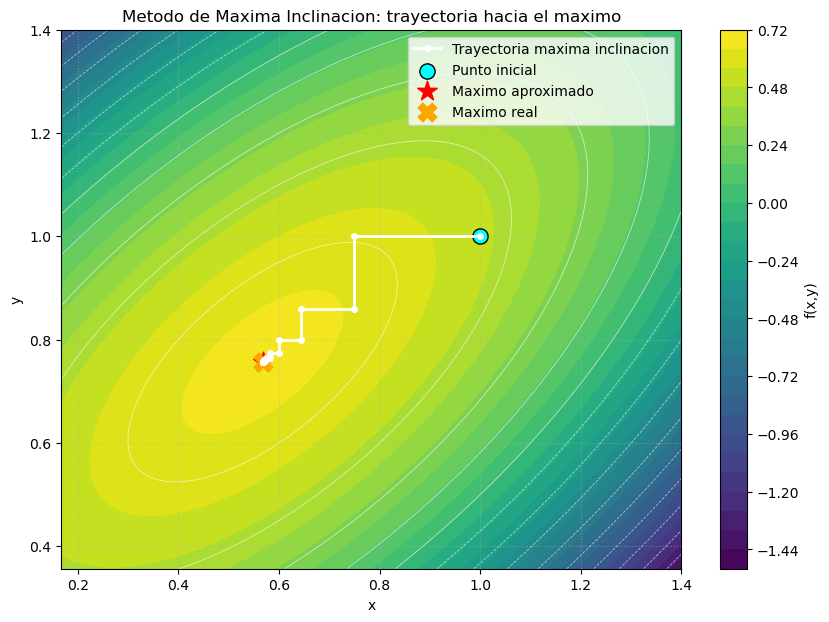

In [5]:
# Grafica de contorno con la trayectoria, maximo real y maximo aproximado
tray_x = [row[1] for row in historial] + [x_aprox]
tray_y = [row[2] for row in historial] + [y_aprox]

xmin = min(min(tray_x), x_real) - 0.4
xmax = max(max(tray_x), x_real) + 0.4
ymin = min(min(tray_y), y_real) - 0.4
ymax = max(max(tray_y), y_real) + 0.4

Xg = np.linspace(xmin, xmax, 250)
Yg = np.linspace(ymin, ymax, 250)
XX, YY = np.meshgrid(Xg, Yg)
ZZ = f_num(XX, YY)

plt.figure(figsize=(10, 7))
cont = plt.contourf(XX, YY, ZZ, levels=30, cmap='viridis')
plt.colorbar(cont, label='f(x,y)')
plt.contour(XX, YY, ZZ, levels=15, colors='white', linewidths=0.6, alpha=0.6)

plt.plot(tray_x, tray_y, 'w.-', linewidth=2, markersize=8, label='Trayectoria maxima inclinacion')
plt.scatter(x0, y0, color='cyan', edgecolors='black', s=120, label='Punto inicial')
plt.scatter(x_aprox, y_aprox, color='red', marker='*', s=220, label='Maximo aproximado')
plt.scatter(x_real, y_real, color='orange', marker='X', s=180, label='Maximo real')

plt.title('Metodo de Maxima Inclinacion: trayectoria hacia el maximo')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

In [ ]:
# Grafica del error por iteracion (distancia al maximo real)
iteraciones = list(range(1, len(historial) + 1))
errores_real = [np.hypot(row[1] - x_real, row[2] - y_real) for row in historial]

plt.figure(figsize=(10, 6))
plt.plot(iteraciones, errores_real, 'o-', color='green', linewidth=2, markersize=6)
plt.yscale('log')
plt.title('Convergencia del error respecto al maximo real')
plt.xlabel('Iteracion')
plt.ylabel('Error de distancia [escala logaritmica]')
plt.grid(True, linestyle=':', alpha=0.7, which='both')
plt.show()

In [7]:
# Tabla de iteraciones: valores y error

tabla_iteraciones = pd.DataFrame(
    historial,
    columns=[
        'Iteración',
        'x_k',
        'y_k',
        'f(x_k, y_k)',
        'df_dx',
        'df_dy',
        'h_opt',
        'Error_paso',
        'Norma_gradiente'
    ]
)

# Formato para lectura más clara
tabla_mostrar = tabla_iteraciones.copy()
tabla_mostrar['x_k'] = tabla_mostrar['x_k'].map(lambda v: f'{v:.6f}')
tabla_mostrar['y_k'] = tabla_mostrar['y_k'].map(lambda v: f'{v:.6f}')
tabla_mostrar['f(x_k, y_k)'] = tabla_mostrar['f(x_k, y_k)'].map(lambda v: f'{v:.6f}')
tabla_mostrar['Error_paso'] = tabla_mostrar['Error_paso'].map(lambda v: f'{v:.3e}')
tabla_mostrar['Norma_gradiente'] = tabla_mostrar['Norma_gradiente'].map(lambda v: f'{v:.3e}')

print('Tabla completa de iteraciones (valores y error):')
print(tabla_mostrar.to_string(index=False))

Tabla completa de iteraciones (valores y error):
 Iteración      x_k      y_k f(x_k, y_k)         df_dx         df_dy    h_opt Error_paso Norma_gradiente
         1 1.000000 1.000000    0.500000 -7.500000e-01  0.000000e+00 0.333333  2.500e-01       7.500e-01
         2 0.750000 1.000000    0.593750  0.000000e+00 -5.625000e-01 0.250000  1.406e-01       5.625e-01
         3 0.750000 0.859375    0.633301 -3.164062e-01  0.000000e+00 0.333333  1.055e-01       3.164e-01
         4 0.644531 0.859375    0.649986  0.000000e+00 -2.373047e-01 0.250000  5.933e-02       2.373e-01
         5 0.644531 0.800049    0.657025 -1.334839e-01  0.000000e+00 0.333333  4.449e-02       1.335e-01
         6 0.600037 0.800049    0.659995  0.000000e+00 -1.001129e-01 0.250000  2.503e-02       1.001e-01
         7 0.600037 0.775021    0.661248 -5.631351e-02  0.000000e+00 0.333333  1.877e-02       5.631e-02
         8 0.581265 0.775021    0.661776  0.000000e+00 -4.223514e-02 0.250000  1.056e-02       4.224e-02
      